# EXAM II - Estiven Castrillon

**Experimental Physics III**

07/03/2025

Schedule: <font color='red'>**3 hrs**</font>

---


In [1]:
# @title Librerias
from matplotlib.image import imread
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.fft import *
from scipy.ndimage import rotate
import plotly.express as px
from scipy.stats import t, poisson, norm

In [2]:
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (8, 5)
})

# Exercise 1 (15%)

Recalling that the Abbe number is defined as
$$V = \frac{n_D - 1}{n_F - n_C},$$

where D, F, and C correspond to the wavelengths 587.6 nm, 486.1 nm, and 656.3 nm, and that the higher the Abbe number, the lower the dispersion of light. If a BK7 glass has refractive indices for D, F, and C equal to 1.5168, 1.5224, and 1.5143, and a BAF10 glass has refractive indices for D, F, and C equal to 1.6700, 1.6800, and 1.6658, is it true that BAF10 glass is more suitable for constructing a lens that forms images without a halo of colors (chromatic aberration)?

In [ ]:
# BK7 glass
d7, f7, c7 = 1.5168, 1.5224, 1.5143

# BAF10 glass
d10, f10, c10 = 1.6700, 1.6800, 1.6658

def abbe_number(d: float, f: float, c: float) -> float:
    """
    Calculate the Abbe number for a given set of refractive indices.
    Using formula V = (d - 1) / (f - c) where d, f, and c are the 
    refractive indices at the d, f, and c spectral lines respectively.

    Parameters:
    d (float): Refractive index at the d spectral line (yellow).
    f (float): Refractive index at the f spectral line (blue).
    c (float): Refractive index at the c spectral line (red).
    Returns:
    float: The Abbe number.
    """
    abbe = (d - 1)/(f - c)
    return abbe

BK7 = round(abbe_number(d7, f7, c7), 3)
BAF10 = round(abbe_number(d10, f10, c10), 3)

print(f"Abbe number for BK7 glass: {BK7}")
print(f"Abbe number for BAF10 glass: {BAF10}")

Número de Abbe para el vidrio BK7: 63.802
Número de Abbe para el vidrio BAF10: 47.183


> Answer: No, it is not true that BAF10 glass is more suitable for constructing a lens that forms images without a halo of colors.  

> The Abbe number is a measure of the chromatic dispersion of an optical material: **the higher the Abbe number, the lower the dispersion of light and, therefore, the lower the chromatic aberration**. In our case, since **BK7 glass has an Abbe number of 63.802**, while **BAF10 glass has an Abbe number of 47.183**, and because BK7 has a higher Abbe number, it means that it disperses light less than BAF10. Thus, **BK7 is more suitable than BAF10 for the construction of lenses that produce sharper images with lower chromatic aberration**.

# Exercise 2 (10%)

In a prism spectrometer, the minimum deviation angle is determined when the observed spectral line remains exactly stationary even as the prism continues to rotate.

> Answer: **True**, the problem does not specify whether a justification is required or not, but my answer is based on pre-laboratory 2.

# Exercise 3 (20%)

The file `data_muones.txt` in this folder contains data on the atmospheric muon rate (Hz) recorded every 50 seconds by a detector. The first column corresponds to time in seconds and the second corresponds to the detection frequency of atmospheric muons in Hz.

a. Plot the atmospheric muon rate (Hz) as a function of relative time. To do this, take the first data point as the initial point ($t = 0$).

b. Obtain the frequency histogram for the number of detections per second and plot it.

c. Write at least two properties that must be satisfied in the detection of atmospheric muons for it to follow a Poisson distribution.

d. Calculate the mean value of the number of detections per second, and construct the theoretical frequency of occurrence plot as a function of the number of detections per second. Overlay the theoretical and experimental plots.

e. In this experiment, what is the probability of observing 45 detections in a 50 s interval?

f. What is the probability of observing 500 detections in 3 minutes?

In [4]:
# Reading the text file as a comma-separated csv
file_path = "data_muones.txt"
df = pd.read_csv(file_path, header=None, names=["Time", "Frequency"], sep=",")

# Adjusting the relative time by taking the first data point as t=0
df["Time"] -= df["Time"].min()

display(df.head(3))

,Time,Frequency
0,0,28
1,50,45
2,100,44


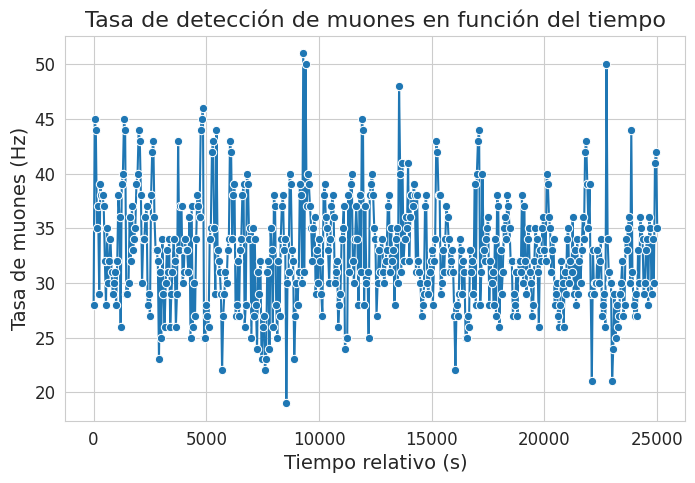

In [ ]:
# a- Muon rate as a function of time
plt.figure(figsize=(8, 5))
sns.lineplot(x=df["Time"], y=df["Frequency"], marker="o", linestyle="-")
plt.xlabel("Relative time (s)")
plt.ylabel("Muon rate (Hz)")
plt.title("Muon detection rate as a function of time")
plt.show()

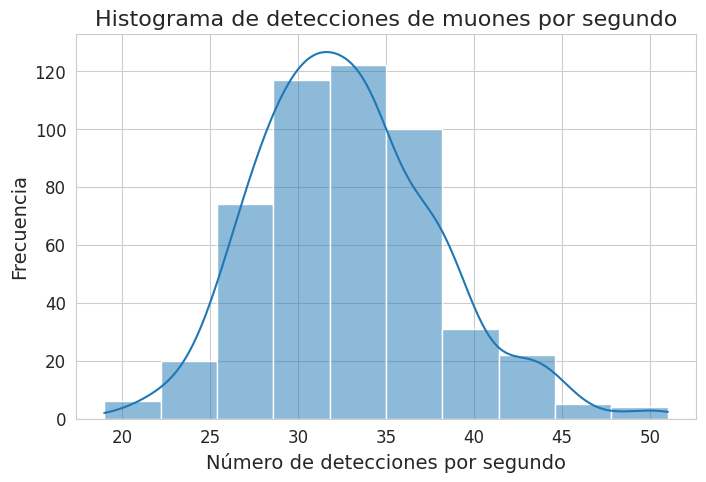

In [ ]:
# b- histogram
plt.figure(figsize=(8, 5))
sns.histplot(df["Frequency"], bins=10, kde=True)
plt.xlabel("Number of detections per second")
plt.ylabel("Frequency")
plt.title("Histogram of muon detections per second")
plt.show()

c) Properties of the Poisson distribution:

- Independent events: The detection of one muon must not influence the detection of another; that is, events must occur randomly and without affecting the probability of future detections.

- Constant rate of occurrence: The average muon detection rate must remain constant over time. If the rate varies significantly due to external factors, the distribution may deviate from a Poisson distribution.

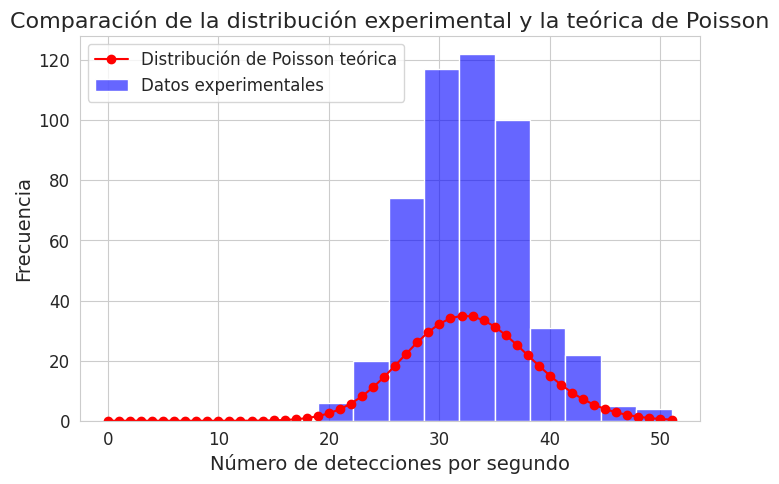

In [ ]:
# d- comparison between experimental and theoretical data
lambda_poisson = df["Frequency"].mean()  # mean detections per second
x = np.arange(0, df["Frequency"].max() + 1)  # possible detection values

# Theoretical Poisson distribution
poisson_theoretical = poisson.pmf(x, mu=lambda_poisson) * len(df)

# Theoretical vs experimental distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Frequency"], bins=10, kde=False, color="blue", alpha=0.6, label="Experimental data")
plt.plot(x, poisson_theoretical, "ro-", label="Theoretical Poisson distribution")
plt.xlabel("Number of detections per second")
plt.ylabel("Frequency")
plt.title("Comparison between experimental and theoretical Poisson distribution")
plt.legend()
plt.show()

In [ ]:
# e- probability of observing exactly 45 detections in 50 s
prob_45 = poisson.pmf(45, mu=lambda_poisson)
print(f"The probability of observing exactly 45 detections in a 50 s interval is: {prob_45:.4f}")

La probabilidad de observar exactamente 45 detecciones en un intervalo de 50 s es: 0.0077


In [ ]:
# f- probability in 3 minutes
T = 3 * 60  # 3 minutes in seconds

# Scaling the Poisson mean to the new time interval
lambda_3min = lambda_poisson * (T / 1)  # normalized per second

# Probability of observing exactly 500 detections in 3 minutes
prob_500 = poisson.pmf(500, mu=lambda_3min)
print(f"The probability of observing exactly 500 detections in 3 minutes is: {prob_500:.4e}")

La probabilidad de observar exactamente 500 detecciones en 3 minutos es: 0.0000e+00


# Point 4 (10%)

Using the t-student table, determine the correction factor for a sample of $n = 18$ data points and a confidence interval of 98%. Provide the full value that appears in the table for a two-tailed test.

![t-student](https://github.com/jmmarinr/FisExperimental3/blob/main/Parciales/Parcial%202/tstudent.png?raw=true)

NOTE: take into account the symmetry of the distribution and that the shaded area corresponds to α.

> Answer

To find the correction value for a 98% confidence interval with 18 samples, we follow this procedure:

$$ \text{We look for the value } t_{\alpha/2, n-1} \text{ where } n = 18 $$

Required parameters:
* Confidence level: 98%
* Significance level: $\alpha = 1 - 0.98 = 0.02$
* Two-tailed test: $\alpha/2 = 0.01$
* Degrees of freedom: $n - 1 = 17$

Therefore, we need to find the value $t_{0.01, 17}$ in the Student’s t-distribution table.

The corresponding correction factor is:

$$ t_{0.01, 17} = 2.567 $$

# Point 5 (15%)

In an experiment, 12 temperature measurements were taken with an average value of 50.1687 °C and a standard deviation of 1.7332 °C. Determine the standard error (s/√n) and report the temperature:

(a) with one standard error,  

(b) with two standard errors,  

(c) with a Student’s t correction with an uncertainty of 10%.

In [5]:
data_points = 12
mean = 50.1687
std_dev = 1.7332

standard_error = std_dev / data_points
print(f"Temperature with one error: {mean:.4f} ± {standard_error:.4f} °C")
print(f"Temperature with two standard errors: {mean:.4f} ± {(2 * standard_error):.4f} °C")

Temperature with one error: 50.1687 ± 0.1444 °C
Temperature with two standard errors: 50.1687 ± 0.2889 °C


> Answer

a. Temperature with one error: 50.1687 ± 0.5003 °C  

b. Temperature with two standard errors: 50.1687 ± 1.0007 °C  

c. Using the same procedure applied in point 4 of the exam: for a 90% confidence interval, we look for the critical value $t_{\alpha/2, n-1}$ where:

* Confidence level: 90%  
* Significance level: $\alpha = 1 - 0.90 = 0.10$  
* Two-tailed test: $\alpha/2 = 0.05$  
* Degrees of freedom: $n - 1 = 11$  

Consulting the Student’s t-distribution table, we find:

$$ t_{0.05, 11} = 1.796 $$

To apply the correction, we multiply this value by the standard error:

$$ t \times \text{standard error} = 1.796 \times 0.144 = 0.2593 $$

Therefore, the temperature report with the Student’s t correction is:

$$ 50.1687 \pm 0.2593 \text{ °C} $$

# Point 6 (30%)

The following is the diffraction image obtained from a grating experiment, where the wavelength of the incident light is $\lambda = 638 \pm 10$ nm. The distance between the screen and the grating is $z = 80 \pm 1$ cm, and the pixel-to-millimeter relation is $50$ px = $1$ mm.

Answer:

a. Normalize the image and convert it to grayscale. Additionally, knowing that $df = \frac{dx}{\lambda z}$, where $dx$ corresponds to the pixel-to-millimeter relation, plot the given image using the appropriate scale, that is [1/m], placing (0,0) at the center.

b. Find the inverse transform of the diffraction pattern and display it with the appropriate scale [m], placing the coordinate (0,0) at the center of the image. For this, remember that in real space $dx_r = \frac{1}{N \cdot df}$, where $N$ is the number of pixels that make up the image. *Hint: remember that the diffraction pattern is given in terms of the squared intensity $|X(f)|^2$, and in real space we do not need to apply ``log``.*

c. Find the width of the grating $D$ along with its error (horizontal distance). To do this, take a cross-section through the coordinate close to $y = 0$. *Hint: normalize the image and to obtain the central coordinate use* ``[len(image)//2]``.

d. Now, knowing that for a grating experiment, the intensity minima $m$ occur at an angle $\theta$ when:

\begin{equation}
D \sin(\theta) = m\lambda,
\end{equation}

find the theoretical position of these minima $x$ (horizontal distance on the screen) for $m = \pm 1, \pm 2, \pm 3$, and determine the value of $D$. For this, express $\sin(\theta)$ in terms of the known variables $x$ and $d$. Compare your results with those obtained through the Fourier transform. *Hint: to visualize the values more easily, take a cross-section of the provided image along the $y = 0$ axis at the central value (middle) and use the $x$ coordinates in meters to find the minima.*

> **The image is NOT in grayscale nor in a single dimension**

In [ ]:
plt.rcdefaults()  # Reestablish default matplotlib settings

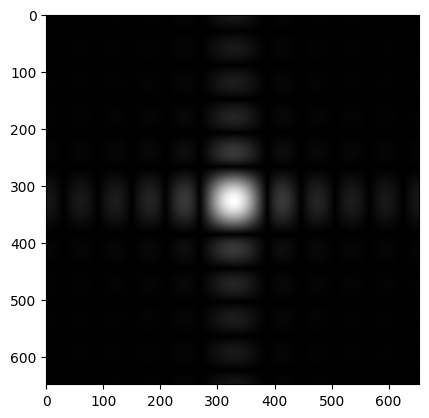

In [8]:
image = imread('pattern.bmp')
plt.imshow(image)
plt.show()

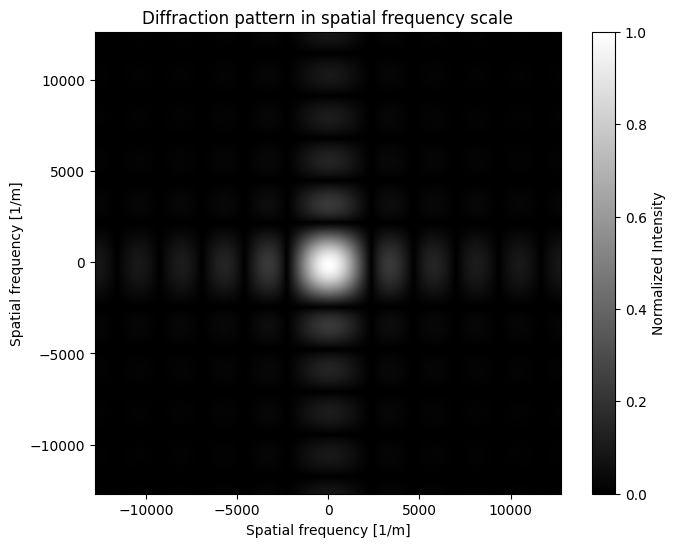

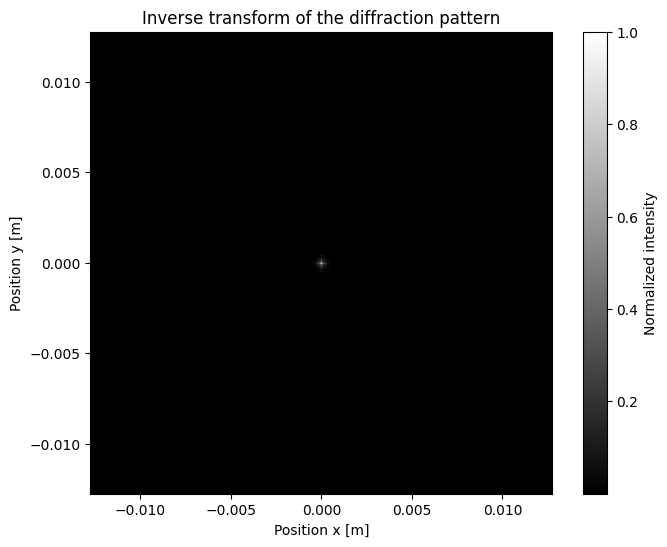

In [23]:
from scipy.fftpack import ifft2, fftshift
from skimage.color import rgb2gray

# Converting the image to grayscale and normalizing it
gray_image = rgb2gray(image)
gray_image /= np.max(gray_image)

# Given data
lambda_m = 638e-9  # Wavelength in nm
z_m = 80e-2  # Grating-screen distance in cm, converted to meters
dx_m = 1 / 50 * 1e-3  # Pixel/mm relation → 50 px = 1 mm, so 1 px = 1/50 mm, converted to meters

# Compute df in Fourier space
df = dx_m / (lambda_m * z_m)  # Using the relation x = lambda * z * f, then df = 1 / (lambda * z) * dx

Ny, Nx = gray_image.shape
fx = (np.arange(Nx) - Nx//2) * df
fy = (np.arange(Ny) - Ny//2) * df

# Image in spatial frequency domain [1/m]
plt.figure(figsize=(8, 6))
plt.imshow(gray_image, extent=[fx.min(), fx.max(), fy.min(), fy.max()], cmap='gray')  # Image with spatial frequency axes
plt.xlabel("Spatial frequency [1/m]")
plt.ylabel("Spatial frequency [1/m]")
plt.title("Diffraction pattern in spatial frequency scale")
plt.colorbar(label="Normalized Intensity")
plt.show()

# Inverse Fourier Transform 

# Pixel size in real space
dx_rx = 1 / (Nx * df)
dx_ry = 1 / (Ny * df)

# Spatial axes
x_vals = np.linspace(-Nx//2, Nx//2, Nx) * dx_rx
y_vals = np.linspace(-Ny//2, Ny//2, Ny) * dx_ry
X, Y = np.meshgrid(x_vals, y_vals)

# Inverse Fourier Transform
ifft_image = np.abs(fftshift(ifft2(ifftshift(gray_image))))  # ifftshift to center the image before and after IFFT2D
ifft_image = ifft_image / np.max(ifft_image)  # Normalization

# Image in real space [m]
plt.figure(figsize=(8, 6))
plt.imshow(ifft_image, cmap='gray', extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()])
plt.colorbar(label="Normalized intensity")
plt.xlabel("Position x [m]")
plt.ylabel("Position y [m]")
plt.title("Inverse transform of the diffraction pattern")
plt.show()

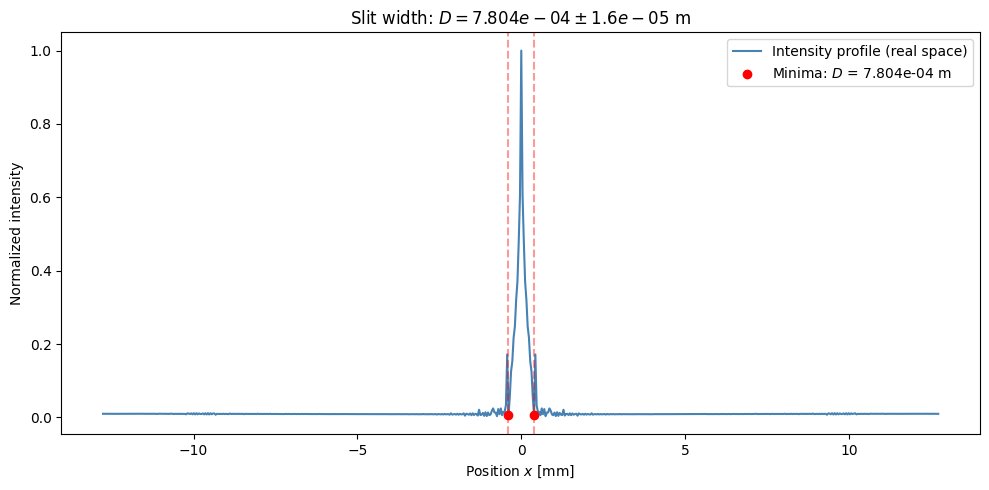

Slit width: D = 7.804e-04 ± 1.6e-05 m
 That is in milimeters: D = 0.780 ± 0.0 mm


In [25]:
from scipy.signal import find_peaks

# Cross-section at y = 0 on the REAL space image (ifft_image)
center_y = ifft_image.shape[0] // 2
intensity_profile = ifft_image[center_y, :]  # Already normalized (divided by its maximum)

# x-axis in meters, using previously computed dx_rx
x_values = (np.arange(Nx) - Nx // 2) * dx_rx  # Consistent with how x_r was constructed

# Find MINIMA of the profile (valleys of the autocorrelation = slit edges)
# Values are inverted so that find_peaks detects valleys as peaks
valleys, props = find_peaks(-intensity_profile, prominence=0.02, distance=3)

# Filter only the valleys closest to the center (first minima, m = ±1)
center_idx = Nx // 2
distances_to_center = np.abs(valleys - center_idx)
sorted_valleys = valleys[np.argsort(distances_to_center)]

if len(sorted_valleys) >= 2:
    # The two valleys closest to the center correspond to the slit edges
    v1, v2 = sorted(sorted_valleys[:2])  # Indices of the two closest valleys to the center

    # Width D = distance between the first two symmetric minima
    D = np.abs(x_values[v2] - x_values[v1])

    # Error: propagation from lambda and z uncertainties
    # D = m*lambda*z / x  →  dD/D = sqrt((dλ/λ)² + (dz/z)²)
    dlambda = 10e-9          # Uncertainty in lambda [m]
    dz = 1e-2                # Uncertainty in z [m]
    lambda_m = 638e-9
    z_m = 0.80
    D_error = D * np.sqrt((dlambda / lambda_m)**2 + (dz / z_m)**2)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(x_values * 1e3, intensity_profile, color='steelblue', label="Intensity profile (real space)")
    plt.scatter(x_values[sorted_valleys[:2]] * 1e3,
                intensity_profile[sorted_valleys[:2]],
                color='red', zorder=5, label=f"Minima: $D$ = {D:.3e} m")
    plt.axvline(x_values[v1] * 1e3, color='red', linestyle='--', alpha=0.4)
    plt.axvline(x_values[v2] * 1e3, color='red', linestyle='--', alpha=0.4)
    plt.xlabel("Position $x$ [mm]")
    plt.ylabel("Normalized intensity")
    plt.title(f"Slit width: $D = {D:.3e} \\pm {D_error:.1e}$ m")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Slit width: D = {D:.3e} ± {D_error:.1e} m\n That is in milimeters: D = {(D * 1e3):.3f} ± {(D_error * 1e3):.1f} mm")

else:
    print(f"Only {len(sorted_valleys)} minima were found. Adjust 'prominence' or 'distance'.")
    # Debug: show full profile for visual inspection
    plt.figure(figsize=(10, 4))
    plt.plot(x_values * 1e3, intensity_profile)
    plt.xlabel("Position $x$ [mm]")
    plt.ylabel("Normalized intensity")
    plt.title("Intensity profile — no minima detected")
    plt.show()

Measured positions of minima [mm]: [-3.54 -2.36 -1.2   1.2   2.36  3.56]
Estimated D per minimum [mm]:      [0.43254661 0.43254425 0.42533381 0.42533381 0.43254425 0.43011662]

D (theoretical minima): 0.430 ± 0.0032 mm
D (Fourier):            0.780 ± 0.0156 mm


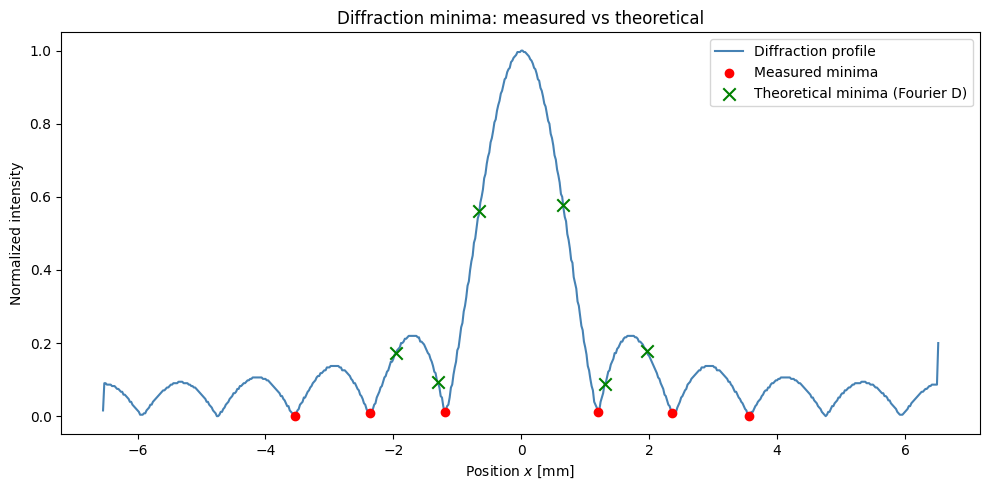

In [28]:
# Cross-section of the ORIGINAL image (diffraction pattern on the screen)
center_y = gray_image.shape[0] // 2
profile_diff = gray_image[center_y, :]

# x-axis in meters using dx (frequency space → screen)
# x_screen = f * lambda * z, but here the axis already represents real position on the screen
x_screen = (np.arange(Nx) - Nx // 2) * dx_m  # dx_m = pixel size in meters

# Find minima in the diffraction pattern
valleys_diff, _ = find_peaks(-profile_diff, prominence=0.02, distance=3)

# Sort by distance to the center and take the 6 closest (m = ±1, ±2, ±3)
center_idx = Nx // 2
valleys_diff = valleys_diff[np.argsort(np.abs(valleys_diff - center_idx))][:6]
valleys_diff = np.sort(valleys_diff)  # reorder from left to right

x_minimos_medidos = x_screen[valleys_diff]  # real positions in meters

# Compute D for each minimum: from D*sin(θ) = m*λ
# sin(θ) = x / sqrt(x² + z²)  →  D = m*λ / sin(θ) = m*λ*sqrt(x²+z²) / x
m_values = np.array([-3, -2, -1, 1, 2, 3])

D_values = (m_values * lambda_m * np.sqrt(x_minimos_medidos**2 + z_m**2)) / x_minimos_medidos

D_teorico_mean = np.mean(D_values)
D_teorico_std  = np.std(D_values)

# Theoretical positions using D from Fourier (for visual comparison)
x_minimos_teo = m_values * lambda_m * z_m / D  # small-angle approximation

# Results
print("Measured positions of minima [mm]:", x_minimos_medidos * 1e3)
print("Estimated D per minimum [mm]:     ", D_values * 1e3)
print(f"\nD (theoretical minima): {D_teorico_mean*1e3:.3f} ± {D_teorico_std*1e3:.4f} mm")
print(f"D (Fourier):            {D*1e3:.3f} ± {D_error*1e3:.4f} mm")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_screen * 1e3, profile_diff, color='steelblue', label="Diffraction profile")
plt.scatter(x_minimos_medidos * 1e3, profile_diff[valleys_diff],
            color='red', zorder=5, label="Measured minima")
plt.scatter(x_minimos_teo * 1e3,
            np.interp(x_minimos_teo, x_screen, profile_diff),
            color='green', marker='x', s=80, zorder=6, label="Theoretical minima (Fourier D)")
plt.xlabel("Position $x$ [mm]")
plt.ylabel("Normalized intensity")
plt.title("Diffraction minima: measured vs theoretical")
plt.legend()
plt.tight_layout()
plt.show()